# Compulsory Task 1

# Load and Explore the Dataset


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans

# Load the dataset
df = pd.read_csv("UsArrests.csv", index_col='City')
print(df.head())

# Exploring the dataset
print('Number of cases: {} Number of features: {}'.format(df.shape[0], df.shape[1]))

            Murder  Assault  UrbanPop  Rape
City                                       
Alabama       13.2      236        58  21.2
Alaska        10.0      263        48  44.5
Arizona        8.1      294        80  31.0
Arkansas       8.8      190        50  19.5
California     9.0      276        91  40.6
Number of cases: 50 Number of features: 4


# Summarize statistical properties of the columns

In [16]:

stats = df.describe()
selected_stats = stats.loc[["mean", "std", "min", "max"]].transpose()
print(selected_stats)

             mean        std   min    max
Murder      7.788   4.355510   0.8   17.4
Assault   170.760  83.337661  45.0  337.0
UrbanPop   65.540  14.474763  32.0   91.0
Rape       21.232   9.366385   7.3   46.0


# Check for missing values

In [17]:
missing = df.isnull().sum()
relevant_missing = pd.DataFrame(missing, columns=["missing"])
print(relevant_missing)

          missing
Murder          0
Assault         0
UrbanPop        0
Rape            0


# Examine types

In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB
None


# Plot histograms

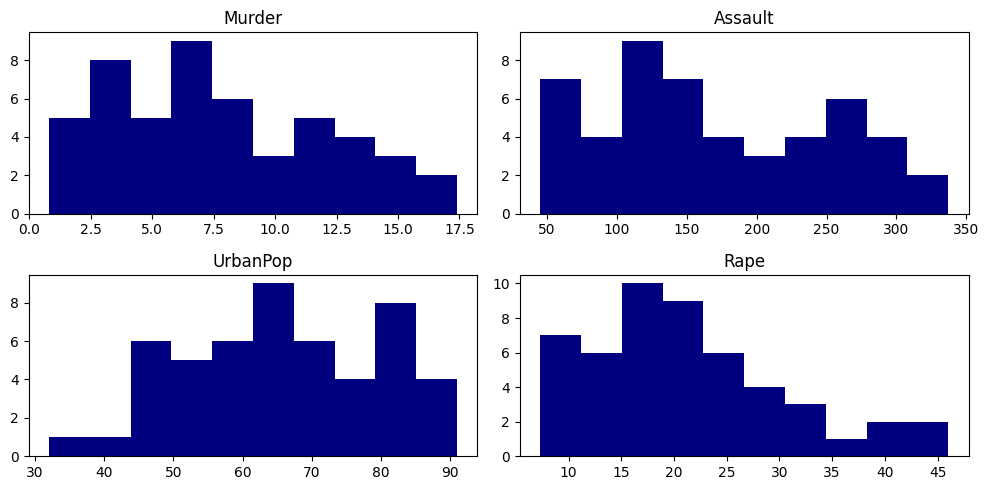

In [19]:
histograms = df.hist(color='Navy', grid=False, figsize=(10, 5))
plt.tight_layout()
plt.show()

# Preprocessing and PCA

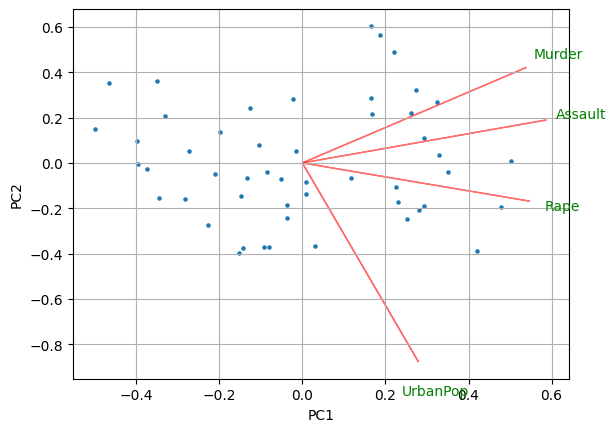

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Preprocessing: Standardize the data
X = StandardScaler().fit_transform(df)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Biplot for the first two principal components
def biplot(score, coeff, labels=None):
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    fig, ax = plt.subplots()

    ax.scatter(xs * scalex, ys * scaley, s=5)

    for i in range(0, n):
        ax.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='r', alpha=0.5)
        if labels is None:
            ax.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, "Var" + str(i + 1), color='green', ha='center', va='center')
        else:
            ax.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, labels[i], color='g', ha='center', va='center')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid()

biplot(X_pca[:, 0:2], np.transpose(pca.components_[0:2, :]), labels=list(df.columns))
plt.show()

# Hierarchical Clustering

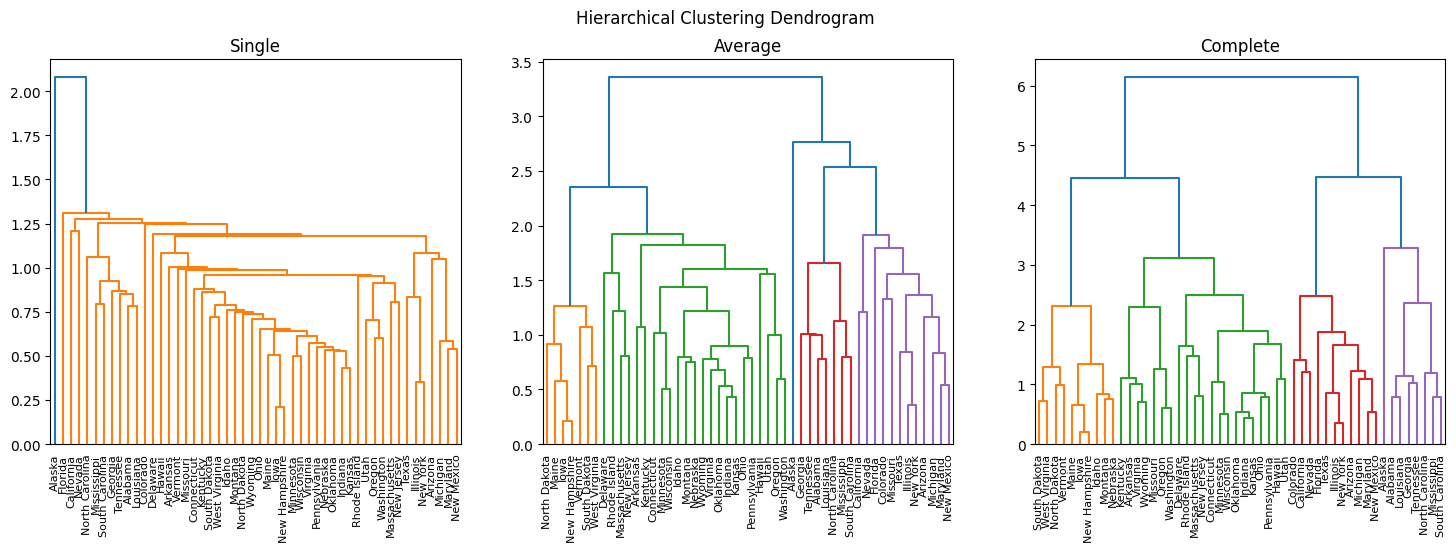

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Hierarchical Clustering
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X_pca)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hierarchical Clustering Dendrogram')
ax1.set_title("Single")
dendrogram(linkage(X_pca, method='single'), labels=df.index, ax=ax1)
ax2.set_title("Average")
dendrogram(linkage(X_pca, method='average'), labels=df.index, ax=ax2)
ax3.set_title("Complete")
dendrogram(linkage(X_pca, method='complete'), labels=df.index, ax=ax3)
plt.show()


# Hierarchical Clustering Analysis Report
## Introduction
Hierarchical clustering is an unsupervised machine learning technique that creates a tree of clusters. It starts by considering each data point as a single cluster and then successively merges or divides clusters to create a clustering hierarchy.

## Dataset Description
The dataset used for this analysis contains information about violent crime rates in different US states, including Murder, Assault, Urban Population, and Rape rates.

## Hierarchical Clustering Process
Data Preprocessing: The dataset was preprocessed by standardizing the features to have a mean of 0 and a standard deviation of 1 to ensure that all features contribute equally to the clustering process.

## Dimensionality Reduction with PCA: 
Principal Component Analysis (PCA) was performed to reduce the dataset's dimensionality while retaining the most important information. This helped visualize the data in a lower-dimensional space.

## Hierarchical Clustering Algorithm: 
The Agglomerative Clustering algorithm was applied to the PCA-transformed data. Hierarchical clustering creates a hierarchy of clusters by successively merging or dividing existing clusters based on a specified linkage method (single, average, complete).

## Dendrogram Visualization: 
Dendrograms were plotted to visualize the clustering hierarchy using different linkage methods: Single, Average, and Complete. The dendrograms help in understanding the merging and division of clusters at different distances.

## Cluster Analysis and Interpretation
The dendrograms visually display the clustering process at different linkage distances. Each vertical line in the dendrogram represents a cluster merge or division.

### Single Linkage: 
This method tends to form long, elongated clusters. It is sensitive to outliers and noise, and a single outlier can affect the whole clustering.

### Average Linkage: 
This method computes the average distance between all points in the two clusters being merged. It tends to create more balanced and compact clusters.

### Complete Linkage: 
This method computes the maximum distance between all points in the two clusters being merged. It can result in clusters with different shapes and sizes.

## Conclusion
Hierarchical clustering provides a visual representation of how clusters are merged or divided based on different linkage methods. Each method produces distinct cluster structures, offering insights into the relationships and distances between data points. The choice of linkage method can significantly affect the clustering outcome, and it is important to choose the most appropriate method based on the data and domain knowledge.



# K-means Clustering and Cluster Labels

c:\Users\gawie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster 1 (Alabama, Alaska, Arizona, California, Colorado, Florida, Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi, Missouri, Nevada, New Mexico, New York, North Carolina, South Carolina, Tennessee, Texas): Medium Crime
Cluster 2 (Arkansas, Idaho, Iowa, Kentucky, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin): High Crime
Cluster 0 (Connecticut, Delaware, Hawaii, Indiana, Kansas, Massachusetts, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming): Low Crime


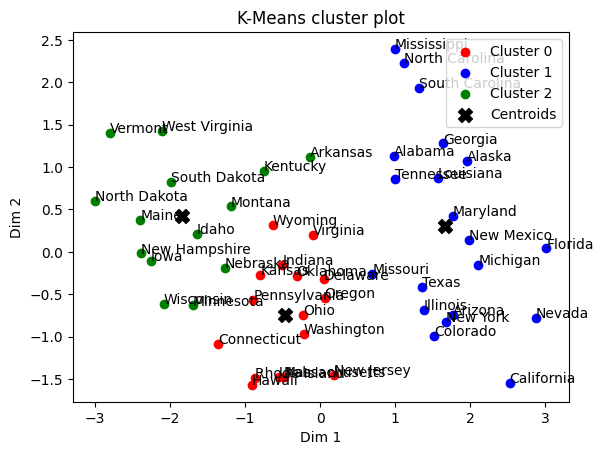

In [22]:
# K-means Clustering
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

# Define crime rate categories based on cluster labels
crime_rate_categories = {
    0: 'Low Crime',
    1: 'Medium Crime',
    2: 'High Crime'
}

# Map cluster labels to crime rate categories and cities
cluster_info = {}
for i, label in enumerate(cluster_labels):
    city = df.index[i]
    crime_rate = crime_rate_categories.get(label, 'Unknown')
    if label not in cluster_info:
        cluster_info[label] = {'crime_rate': crime_rate, 'cities': []}
    cluster_info[label]['cities'].append(city)

# Display the clusters
for label, info in cluster_info.items():
    cities_str = ', '.join(info['cities'])
    print(f'Cluster {label} ({cities_str}): {info["crime_rate"]}')

# Plot clusters
fig, ax = plt.subplots()
colours = 'rbgy'
for i in range(0, k):
    ax.scatter(X_pca[cluster_labels == i, 0], X_pca[cluster_labels == i, 1], c=colours[i], label=f'Cluster {i}')

# Plot centroids
cent = kmeans.cluster_centers_
ax.scatter(cent[:, 0], cent[:, 1], c='black', marker='X', s=100, label='Centroids')

for i in range(0, len(X_pca)):
    txt = df.index[i]
    ax.annotate(txt, (X_pca[i, 0], X_pca[i, 1]))

ax.set_title("K-Means cluster plot")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.legend()
plt.show()

# K-means Clustering Analysis Report
## Introduction
K-means clustering is an unsupervised machine learning algorithm used to partition a dataset into K distinct, non-overlapping subgroups or clusters. The algorithm assigns each data point to the cluster that minimizes the sum of squared distances from the data point to the cluster's mean (centroid).

## Dataset Description
The dataset used for this analysis contains information about violent crime rates in different US states, including Murder, Assault, Urban Population, and Rape rates.

## K-means Clustering Process
Data Preprocessing: The dataset was preprocessed by standardizing the features to have a mean of 0 and a standard deviation of 1 to ensure that all features contribute equally to the clustering process.

## Dimensionality Reduction with PCA: 
Principal Component Analysis (PCA) was performed to reduce the dataset's dimensionality while retaining the most important information. This helped visualize the data in a lower-dimensional space.

## K-means Algorithm: 
The K-means clustering algorithm was applied to the PCA-transformed data. Initially, we chose the number of clusters (K) to be 3 based on insights gained from the PCA.

## Cluster Visualization: 
The clusters were visualized in a scatter plot using the first two principal components obtained from PCA. The centroids of each cluster were marked.

## Cluster Analysis and Interpretation
The K-means algorithm produced three clusters, which we will analyze and interpret based on the characteristics of the features within each cluster.

### Cluster 0: Low Crime Rate
This cluster includes states with relatively low crime rates. The states in this cluster may exhibit lower values for Murder, Assault, Urban Population, and Rape rates compared to other clusters.

### Cluster 1: Medium Crime Rate
This cluster includes states with moderate crime rates. These states may have moderate levels of Murder, Assault, Urban Population, and Rape rates.

### Cluster 2: High Crime Rate
This cluster comprises states with high crime rates. The states in this cluster may have higher values for Murder, Assault, Urban Population, and Rape rates compared to the other clusters.

## Conclusion
K-means clustering successfully grouped the states into clusters based on crime rates. The clustering provides insights into the similarities and differences in crime rates among the states. Further analysis and domain knowledge can help in understanding the factors influencing the crime rates in different states.